<a href="https://colab.research.google.com/github/Isratjahan1765/Isratjahan1765/blob/main/Lab_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/mirsazzathossain/CSE317-Lab/blob/main/Lab_Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **Find the following integral using the simpson's 1/3 rule**

Simpson's 1/3 rule uses higher-order polynomials to approximate the integral of a function $f(x)$ over the interval $[a,b]$. For Example, if there is an extra point midway between $f(a)$ and $f(b)$, the three points can be connected with a parabola. The area under the parabola is an approximation of the integral of $f(x)$ over the interval $[a,b]$.

<center>
    <img src="https://github.com/mirsazzathossain/CSE317-Lab/blob/main/images/simpson.PNG?raw=1" width="400" />
</center>

If we are given values of $f(x)$ at 3 points as $(x_0, f(x_0))$, $(x_1, f(x_1))$, and $(x_2, f(x_2))$ then we can estimate $f(x)$ using the Lagrange polynomial of degree 2:

$$
\begin{align*}
f(x) &\approx f(x_0) \frac{(x-x_1)(x-x_2)}{(x_0-x_1)(x_0-x_2)} + f(x_1) \frac{(x-x_0)(x-x_2)}{(x_1-x_0)(x_1-x_2)} + f(x_2) \frac{(x-x_0)(x-x_1)}{(x_2-x_0)(x_2-x_1)}
\end{align*}
$$

Now, as the area under the estimated curve is an approximation of the integral of $f(x)$ over the interval $[a,b]$, we can write the integral as:

$$
\begin{align*}
I &= \int_{a}^{b} f(x) dx \\
&\approx \int_{a}^{b} \left[f(x_0)\frac{(x-x_1)(x-x_2)}{(x_0-x_1)(x_0-x_2)} + f(x_1) \frac{(x-x_0)(x-x_2)}{(x_1-x_0)(x_1-x_2)} + f(x_2) \frac{(x-x_0)(x-x_1)}{(x_2-x_0)(x_2-x_1)} \right] dx
\end{align*}
$$

When $a = x_0$, $b = x_2$, $x_1 = \frac{a+b}{2}$, and $h = \frac{b-a}{2}$, we can simplify the integral to:

$$
\begin{align*}
    I &\approx \frac{h}{3} \left[ f(x_0) + 4f(x_1) + f(x_2) \right] \\
    &= (b-a) \frac{f(x_0) + 4f(x_1) + f(x_2)}{6}
\end{align*}
$$

We will use Simpson's 1/3 rule to approximate the integral of $f(x) = 0.2 + 25x - 200x^2 + 675x^3 - 900x^4 + 400x^5$ over the interval $[0, 0.8]$. Follow the steps below to approximate the integral using Simpson's 1/3 rule.

##### **Step 1: Define the function**

Define a function `f` that takes a single parameter `x` and returns the value of $f(x) = 0.2 + 25x - 200x^2 + 675x^3 - 900x^4 + 400x^5$ at `x`. Note that the function should be able to handle both scalar and vector inputs.


In [1]:
import numpy as np

def f(x):
    return 0.2 + 25*x - 200*x**2 + 675*x**3 - 900*x**4 + 400*x**5

##### **Step 2: Define a function to approximate the function $f(x)$ using Lagrange polynomial**

Define a function `lagrange` that takes four parameters `x0`, `x1`, `x2` and `x` and returns the value of the Lagrange polynomial of degree 2 at `x`. The function should be able to handle both scalar and vector inputs. Use the function `f` defined in Step 1 to evaluate the function at the given points.

In [2]:
def lagrange(x0, x1, x2, x):
    return (f(x0) * ((x - x1)*(x - x2))/((x0 - x1)*(x0 - x2)) +
            f(x1) * ((x - x0)*(x - x2))/((x1 - x0)*(x1 - x2)) +
            f(x2) * ((x - x0)*(x - x1))/((x2 - x0)*(x2 - x1)))

##### **Step 3: Define the interval**
Define the interval as a numpy array of two elements, where the first element is the lower bound and the second element is the upper bound. Name the array `interval`.

In [3]:
interval = np.array([0, 0.8])

##### **Step 4: Plot the function and the approximated polynomial**

Plot the function $f(x)$ and the approximated polynomial using the function `lagrange` defined in Step 2. Use the interval defined in Step 3 as the x-axis. Also, plot the points $(x_0, f(x_0))$, $(x_1, f(x_1))$, and $(x_2, f(x_2))$ on the same plot. Fill the area under the approximated polynomial using numpy's `fill_between` function.

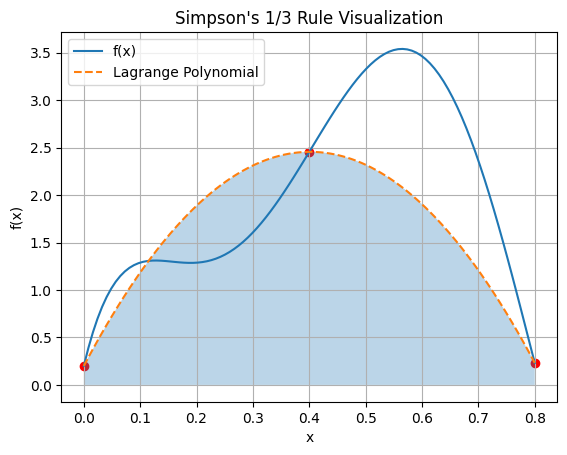

In [4]:
import matplotlib.pyplot as plt

a = interval[0]
b = interval[1]

x0 = a
x2 = b
x1 = (a + b) / 2

x_vals = np.linspace(a, b, 100)

y_vals = f(x_vals)
y_lagrange = lagrange(x0, x1, x2, x_vals)

plt.figure()
plt.plot(x_vals, y_vals, label="f(x)")
plt.plot(x_vals, y_lagrange, '--', label="Lagrange Polynomial")

plt.scatter([x0, x1, x2], [f(x0), f(x1), f(x2)], color='red')

plt.fill_between(x_vals, y_lagrange, alpha=0.3)

plt.title("Simpson's 1/3 Rule Visualization")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

##### **Step 5: Define a function to approximate the integral using Simpson's 1/3 rule**

Define a function `simpson` that takes a parameter `interval` and returns the approximate value of the integral of $f(x)$ over the interval `interval` using Simpson's 1/3 rule. You have to employ the following steps:

*   Calculate the midpoint of the interval. Store the value in a variable named `midpoint`.
*   Calculate the value of $f(x_0)$, $f(x_1)$, and $f(x_2)$, where $x_0 = a$, $x_1 = \frac{a+b}{2} = midpoint$, and $x_2 = b$. Store the values in variables named `f0`, `f1`, and `f2` respectively.
*   Calculate the approximate value of the integral using Simpson's 1/3 rule. Store the value in a variable named `I`.
*   Return the value of `I`.

In [5]:
def simpson(interval):
    a = interval[0]
    b = interval[1]

    midpoint = (a + b) / 2

    f0 = f(a)
    f1 = f(midpoint)
    f2 = f(b)

    I = (b - a) / 6 * (f0 + 4*f1 + f2)

    return I

##### **Step 6: Approximate the integral using Simpson's 1/3 rule**

Call the function `simpson` with the interval `interval` as the parameter. Store the value returned by the function in a variable named `I`. Print the value of `I`. Then you should compute the integral analytically and find the absolute relative error between the two values. Print the absolute relative error.

In [6]:
I = simpson(interval)
print("Simpson Approximation =", I)


# Exact integration
import sympy as sp

x = sp.symbols('x')

f_sym = 0.2 + 25*x - 200*x**2 + 675*x**3 - 900*x**4 + 400*x**5

I_exact = sp.integrate(f_sym, (x, interval[0], interval[1]))
I_exact = float(I_exact)

print("Exact Integral =", I_exact)


# Absolute Relative Error
error = abs((I_exact - I) / I_exact)

print("Absolute Relative Error =", error)

Simpson Approximation = 1.3674666666666742
Exact Integral = 1.6405333333333303
Absolute Relative Error = 0.16644993498048805
